In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [3]:
path = "D:\\Ameng\\Data Science Project\\Student-Grade-Analysis\\data\\student-mat.csv"
df = pd.read_csv(path, sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

In [6]:
df.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## Unvariate Analysis

Analyze only one column/variable at a time. In this case it is G3 (final grade).

In [7]:
print(df['G3'].describe())

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


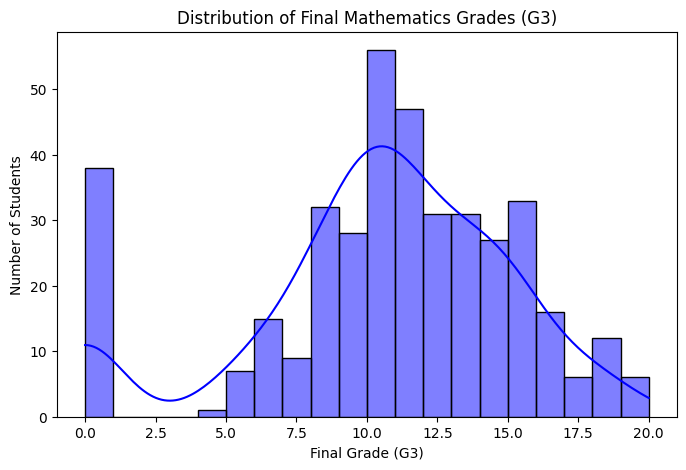

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='blue')
plt.title('Distribution of Final Mathematics Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.show()

From that histogram distribution, majority students grades is in range 8 to 15, with a peak grades around 10 to 11. However, there is a notable anomaly where a significant number of students scored exactly 0.

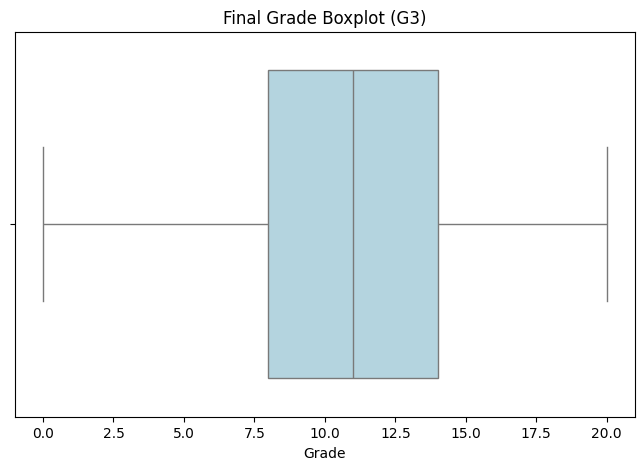

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['G3'], color='lightblue')
plt.title('Final Grade Boxplot (G3)')
plt.xlabel('Grade')
plt.show()

From that box plot, we can see that there are no outliers. The middle 50% of the students scored between 8 to 14, with the median of the grades at 11. Although the score of 0 seemed like an anomaly in the histogram, mathemathically it falls within the lower bound whisker limit, indicating a wide spread of lower grades rather than a few isolated extreme cases.

## Bivariate Analysis

Analyze the relationship between two columns/variables at once.

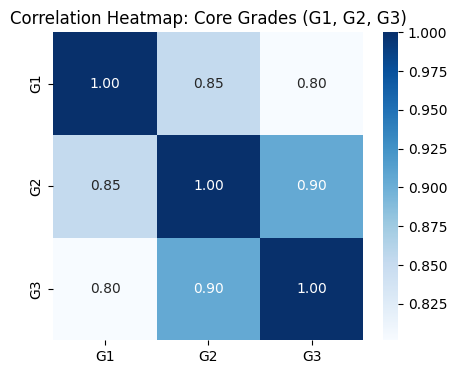

In [10]:
numeric_cols = df.select_dtypes(include=[np.number])
core_grades = numeric_cols[['G1', 'G2', 'G3']]

plt.figure(figsize=(5, 4))
sns.heatmap(core_grades.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap: Core Grades (G1, G2, G3)')
plt.show()

Each grade has a strong correlation with each other. Especially G1 and G3, G2 and G3 has very high correlation, approaching 1 (0.90). This confirms that the previous grade almost determines the entire final value.

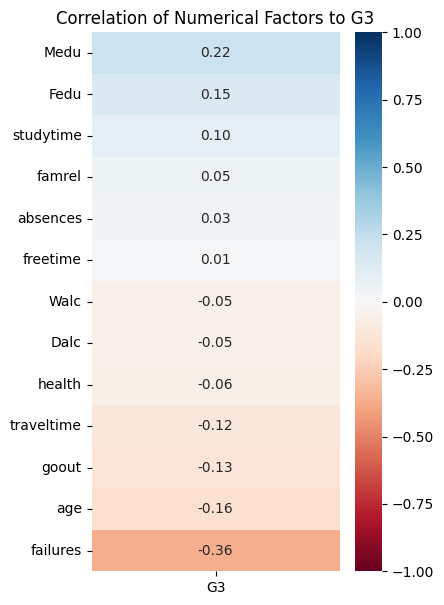

In [11]:
external_factors = numeric_cols.drop(['G1', 'G2'], axis=1)
corr_with_g3 = external_factors.corr()[['G3']].sort_values(by='G3', ascending=False)

plt.figure(figsize=(4, 7))
sns.heatmap(corr_with_g3.drop('G3'), annot=True, cmap='RdBu', fmt='.2f',  vmin=-1, vmax=1)
plt.title('Correlation of Numerical Factors to G3')
plt.show()

From the external numerical factors heatmap, we can observe that:

Top positive factors: Medu (Mother's education), Fedu (Father's education), and studytime have the strongest positive correlation, meaning they tend to help increase the final grade.

Top negative factors: failures (past class failures) has a strong negative correlation, significantly lowering grades. Other moderate negative impacts include goout (going out with friends), age, and absences.

Factors like family relationships (famrel) or health show almost no statistical correlation to final math grades.

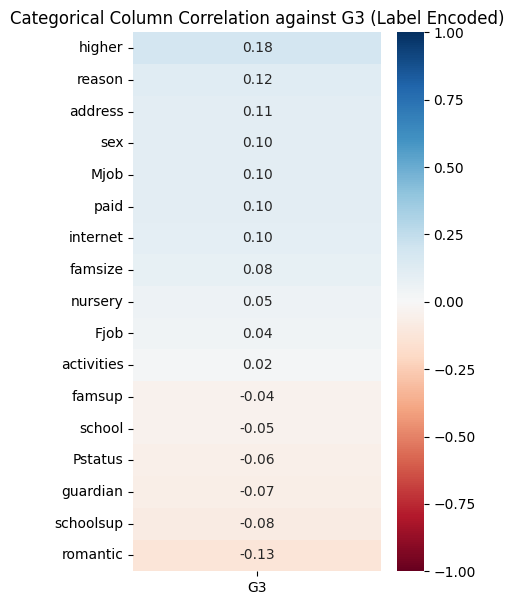

In [17]:
categorical_cols = df.select_dtypes(include=['object']).copy()
categorical_cols['G3'] = df['G3']

le = LabelEncoder()

for col in categorical_cols.columns:
    if categorical_cols[col].dtype == 'object':
        categorical_cols[col] = le.fit_transform(categorical_cols[col])

cat_corr = categorical_cols.corr()[['G3']].sort_values(by='G3', ascending=False)

plt.figure(figsize=(4, 7))
sns.heatmap(cat_corr.drop('G3'), annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Categorical Column Correlation against G3 (Label Encoded)')
plt.show()

From the categorical column correlation against G3, we can observe that:

Top positive factors: higher shows the strongest positive correlation, followed by reason and address. This suggests that students who want to pursue higher education, have specific school-choice reasons, or live in certain address types tend to achieve slightly higher final grades.

Top negative factors: romantic has the strongest negative correlation, followed by schoolsup  and guardian. This indicates that students who are in a romantic relationship, receive school support, or have certain guardian types tend to have slightly lower final grades.

Overall, the correlations are relatively small (close to 0), which means categorical factors have weaker influence compared to numerical factors such as studytime or failures.

C:\Users\akmal\AppData\Local\Temp\ipykernel_9872\1346814038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=df, ax=axes[r, c], palette='Set2', legend='False')
C:\Users\akmal\AppData\Local\Temp\ipykernel_9872\1346814038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=df, ax=axes[r, c], palette='Set2', legend='False')
C:\Users\akmal\AppData\Local\Temp\ipykernel_9872\1346814038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=df, ax=axes[r, c], palette='Set2', legend='False'

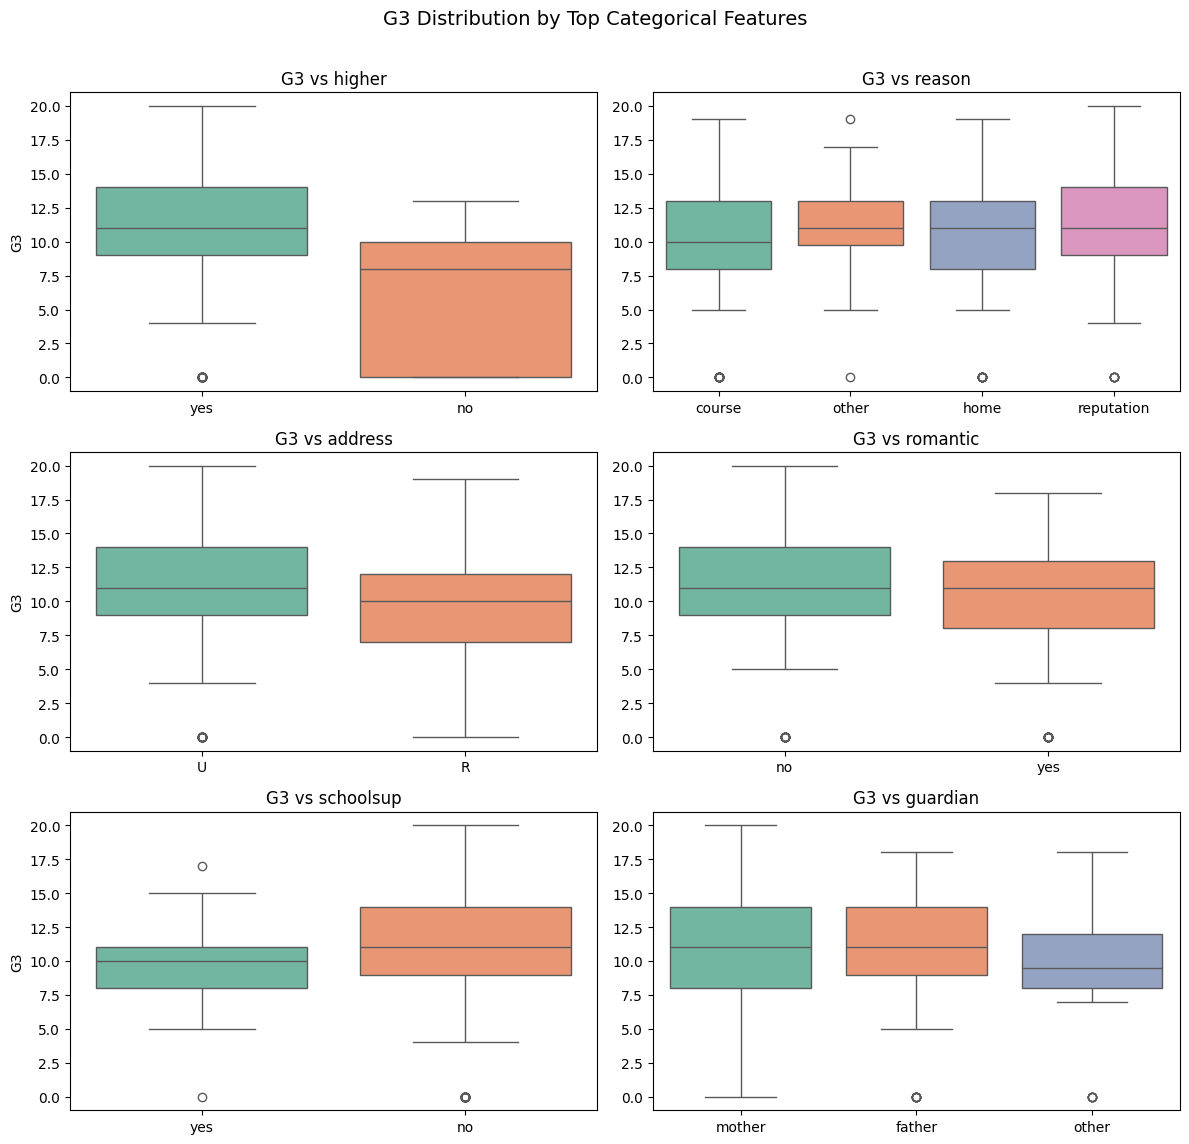

In [23]:
top_cat_cols = ['higher', 'reason', 'address', 'romantic', 'schoolsup', 'guardian']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('G3 Distribution by Top Categorical Features', fontsize=14)

for i, col in enumerate(top_cat_cols):
    r, c = divmod(i, 2)
    sns.boxplot(x=col, y='G3', data=df, ax=axes[r, c], palette='Set2', legend='False')
    axes[r, c].set_title(f'G3 vs {col}')
    axes[r, c].set_xlabel('')
    axes[r, c].set_ylabel('G3' if c == 0 else '')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


From the boxplots, we can conclude:

- higher: The median G3 for the "yes" category is higher than for "no." This indicates that students who want to continue their education tend to have better final grades.
- reason: The categories "other," "home," and "reputation" have similar medians, slightly higher than for "course." This indicates that the reason for choosing a school is not a significant factor, but the reason for "course" tends to be slightly lower.
- address: Students with a "U" (urban) address have a higher median G3 than those with "R" (rural), indicating a slight advantage for urban students.
- romantic: The medians for "yes" and "no" are nearly identical, so romantic relationships do not appear to be a significant factor in differentiating grades.
- schoolsup: The median for "no" is higher than for "yes," indicating that students who need school support tend to have lower grades.
- guardian: The medians for "mother" and "father" are nearly identical, both higher than those for "other." This means that students who are cared for by their own parents tend to have better grades than those who are cared for by other than their parents.